In [14]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
"""------------------Loading Data--------------------"""

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import transforms

train_transform = transforms.Compose([

    # 1️⃣ Randomly rotate the image
    transforms.RandomRotation(
        degrees=10,              # max rotation angle (±10 degrees)
        interpolation=transforms.InterpolationMode.NEAREST,
        expand=False,             # keep original image size
        center=None,              # rotate around image center
        fill=0                    # fill empty pixels with black
    ),

    # 2️⃣ Random affine transformation (translation + scaling)
    transforms.RandomAffine(
        degrees=0,                # no additional rotation here
        translate=(0.1, 0.1),     # max horizontal & vertical shift (fraction of image)
        scale=(0.9, 1.1),         # zoom range: 90%–110%
        shear=None,               # no shearing
        interpolation=transforms.InterpolationMode.NEAREST,
        fill=0                    # fill empty pixels with black
    ),

    # 3️⃣ Convert PIL image → PyTorch tensor
    transforms.ToTensor(),        # converts to FloatTensor in [0, 1]

])

train_ds = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.MNIST(
    root="data",
    train=False,
    transform=transform
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)


In [16]:
"""------------------Designing the Model--------------------"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN,self).__init__()

        self.convolution1 = nn.Conv2d(
            in_channels = 1,
            out_channels = 32,
            kernel_size = 3
            )
        
        self.convolution2 = nn.Conv2d(
            in_channels = 32,
            out_channels = 64,
            kernel_size = 3
            )
        
        self.pool = nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
            )
        
        self.fullconn1 = nn.Linear(
            in_features = 64*5*5,
            out_features = 128
            )
        
        self.fullconn2 = nn.Linear(
            in_features = 128,
            out_features = 10
            )
    def forward(self,x):
        x = self.pool(F.relu(self.convolution1(x)))
        x = self.pool(F.relu(self.convolution2(x)))

        x = torch.flatten(input = x, start_dim = 1)

        x = F.relu(self.fullconn1(x))
        x = self.fullconn2(x)

        return x

In [17]:
"""------------------Move Model to GPU--------------------"""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitCNN().to(device)

In [18]:
"""------------------Setting the Loss Function and Optimizer--------------------"""

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
"""------------------Training Loop (THE BEANS)--------------------"""
import time
import torch

epochs = 50
patience = 7

best_val_loss = float("inf")
epochs_no_improve = 0

history_val_loss = []
history_val_acc = []

for epoch in range(epochs):
    start = time.perf_counter()

    """------------------- Train --------------------"""
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total

    """------------------- Validate --------------------"""
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(test_loader)
    val_accuracy = val_correct / val_total

    history_val_loss.append(val_loss)
    history_val_acc.append(val_accuracy)

    """------------------- Early Stopping & Save --------------------"""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("💾Best Model Saved")
    else:
        epochs_no_improve += 1

    end = time.perf_counter()
    time_taken = end - start

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {time_taken:.2f}s"
    )

    if epochs_no_improve >= patience:
        print(
            f"Early stopping triggered at epoch {epoch+1} "
            f"(no val loss improvement for {patience} epochs)"
        )
        break


Epoch 01 | Train Loss: 0.1772 | Train Acc: 0.9459 | Val Loss: 0.0492 | Val Acc: 0.9845 | Time: 6.06s
Epoch 02 | Train Loss: 0.0508 | Train Acc: 0.9845 | Val Loss: 0.0368 | Val Acc: 0.9882 | Time: 5.30s
Epoch 03 | Train Loss: 0.0344 | Train Acc: 0.9897 | Val Loss: 0.0324 | Val Acc: 0.9890 | Time: 5.43s
Epoch 04 | Train Loss: 0.0256 | Train Acc: 0.9919 | Val Loss: 0.0302 | Val Acc: 0.9900 | Time: 5.57s
Epoch 05 | Train Loss: 0.0207 | Train Acc: 0.9931 | Val Loss: 0.0314 | Val Acc: 0.9895 | Time: 5.35s
Epoch 06 | Train Loss: 0.0158 | Train Acc: 0.9947 | Val Loss: 0.0279 | Val Acc: 0.9916 | Time: 5.48s
Epoch 07 | Train Loss: 0.0114 | Train Acc: 0.9964 | Val Loss: 0.0322 | Val Acc: 0.9904 | Time: 5.47s
Epoch 08 | Train Loss: 0.0105 | Train Acc: 0.9963 | Val Loss: 0.0293 | Val Acc: 0.9914 | Time: 5.46s
Epoch 09 | Train Loss: 0.0080 | Train Acc: 0.9974 | Val Loss: 0.0296 | Val Acc: 0.9912 | Time: 5.47s
Epoch 10 | Train Loss: 0.0064 | Train Acc: 0.9979 | Val Loss: 0.0358 | Val Acc: 0.9910 | Ti

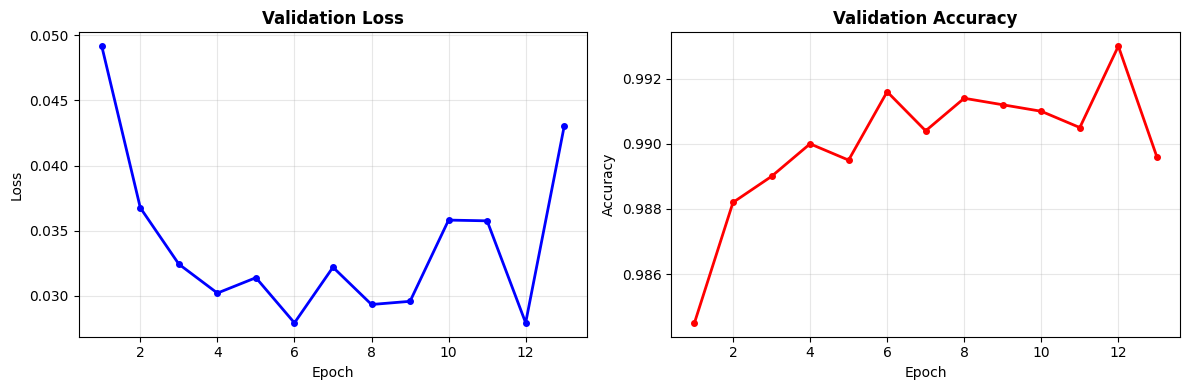


✓ Best Validation Accuracy: 0.9930 (99.30%)
✓ Best Validation Loss: 0.0279


In [20]:

"""------------------Plot Validation Metrics--------------------"""
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history_val_loss) + 1)

# Plot Validation Loss
ax1.plot(epochs_range, history_val_loss, 'b-o', linewidth=2, markersize=4)
ax1.set_title('Validation Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Plot Validation Accuracy
ax2.plot(epochs_range, history_val_acc, 'r-o', linewidth=2, markersize=4)
ax2.set_title('Validation Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Best Validation Accuracy: {max(history_val_acc):.4f} ({max(history_val_acc)*100:.2f}%)")
print(f"✓ Best Validation Loss: {min(history_val_loss):.4f}")